## 1. Introduction

In this notebook, I build an AI model for Jugo to automatically analyze dashboard images and check whether they follow IBCS (International Business Communication Standards).


The goal is to answer two key questions:


Can the model recognize IBCS scenario rules?

Can the model provide feedback per rule?

I focus on four IBCS rules:

Actual (AC)

Previous Year (PY)

Plan (PL)

Forecast (FC)


Each rule is predicted separately using a multi-label classification approach.

## 2. Dataset Description

The dataset contains dashboard images divided into two folders:

compliant

non-compliant

Additionally, a file called labels.csv provides detailed labels:

image	          AC	PY	 PL	  FC

compliant/1.png	   1	0	 0	   0

Each value represents whether a rule is correctly applied:

1 = correct

0 = incorrect

## 3. Import Libraries

In [1]:

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split


I use PyTorch for building the model.

PIL is used to load images.

Pandas is used to read the CSV file.

## 4. Configuration

In [2]:
data_dir = "../images_data"
IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Images are resized to 128x128 pixels.

GPU is used if available for faster training.

## 5. Load Labels

In [3]:
df = pd.read_csv("../images_data/labels.csv", sep=";")
df.head(10)

,image,AC,PY,PL,FC
0,compliant/1.png,1,0,0,0
1,compliant/2.png,1,1,0,0
2,compliant/3.png,1,1,1,0
3,compliant/4.png,1,1,1,0
4,compliant/5.png,1,1,1,1
5,compliant/6.png,1,1,1,1
6,compliant/7.png,1,1,1,1
7,compliant/8.png,1,0,0,0
8,compliant/9.png,1,1,1,1
9,compliant/10.png,1,0,1,1


## 6. Image Transformations

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

Resize ensures all images have the same size.

ToTensor converts images into values between 0 and 1..

## 7. Custom Dataset Class

In [5]:
class MultiLabelDataset(Dataset):
    def __init__(self, data_dir, dataframe, transform=None):
        self.data_dir = data_dir
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, relative_path):
        # Normalize separators and try the path from labels.csv first.
        clean_relative = relative_path.replace("\\", "/").strip()
        img_path = os.path.normpath(os.path.join(self.data_dir, clean_relative))
        if os.path.exists(img_path):
            return img_path

        # If extension does not match actual file, try common image formats.
        base, _ = os.path.splitext(img_path)
        for ext in [".png", ".webp", ".jpg", ".jpeg"]:
            candidate = base + ext
            if os.path.exists(candidate):
                return candidate

        raise FileNotFoundError(f"Image not found: {relative_path}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_image_path(row["image"])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([
            row["AC"],
            row["PY"],
            row["PL"],
            row["FC"]
        ], dtype=torch.float32)

        return img, label

Each image now has 4 labels instead of 1.

This allows the model to learn each rule separately.

## 8. Create Dataset and Split

In [6]:
dataset = MultiLabelDataset(data_dir, df, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Data is split into training, validation, and test sets.

This helps evaluate model performance correctly.

## 9. Model (ResNet18 Transfer Learning)

In [7]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(DEVICE)

I used a pretrained ResNet18 model.

Final layer is changed to output 4 values (one per rule).

## 10. Loss and Optimizer

In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

BCEWithLogitsLoss is used for multi-label classification.

Each rule is treated independently.

## 11. Training Loop

In [9]:
history = {"loss": [], "accuracy": []}

for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).float().mean().item()

    accuracy = correct / len(train_loader)

    history["loss"].append(total_loss / len(train_loader))
    history["accuracy"].append(accuracy)

    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={accuracy:.2f}")

Epoch 1: Loss=1.5192, Accuracy=0.51
Epoch 2: Loss=0.6039, Accuracy=0.86
Epoch 3: Loss=0.1473, Accuracy=1.00
Epoch 4: Loss=0.0930, Accuracy=1.00
Epoch 5: Loss=0.0531, Accuracy=1.00
Epoch 6: Loss=0.0505, Accuracy=1.00
Epoch 7: Loss=0.0775, Accuracy=1.00
Epoch 8: Loss=0.0957, Accuracy=0.98
Epoch 9: Loss=0.4921, Accuracy=0.92
Epoch 10: Loss=0.0752, Accuracy=1.00


The model learns to predict all four rules at once.

Accuracy represents how many rules are predicted correctly.

## 12. Plot Results

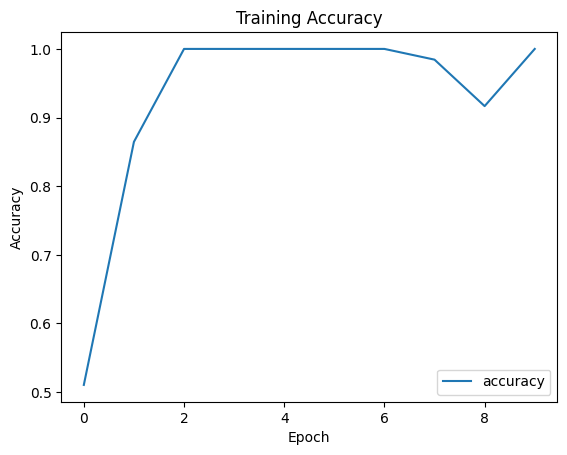

In [10]:
plt.plot(history["accuracy"], label='accuracy')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 13. Predictions and Feedback

In [11]:
def generate_feedback(pred):
    feedback = []

    if pred[0] < 0.5:
        feedback.append("Actual should be dark solid color")

    if pred[1] < 0.5:
        feedback.append("Previous Year should be lighter than Actual")

    if pred[2] < 0.5:
        feedback.append("Plan should be outlined")

    if pred[3] < 0.5:
        feedback.append("Forecast should use hatched pattern")

    return feedback

## 14. Test Predictions

In [12]:
model.eval()

with torch.no_grad():
    for i, (img, label) in enumerate(dataset):
        if i >= 5:
            break

        img = img.unsqueeze(0).to(DEVICE)
        output = model(img)
        pred = torch.sigmoid(output).cpu().numpy()[0]

        print("Prediction:", pred)
        print("Actual:", label.numpy())
        print("Feedback:", generate_feedback(pred))
        print("------")

Prediction: [9.9999833e-01 2.5798206e-04 1.0246738e-03 3.6006698e-03]
Actual: [1. 0. 0. 0.]
Feedback: ['Previous Year should be lighter than Actual', 'Plan should be outlined', 'Forecast should use hatched pattern']
------
Prediction: [0.99916553 0.9993193  0.00479421 0.00159902]
Actual: [1. 1. 0. 0.]
Feedback: ['Plan should be outlined', 'Forecast should use hatched pattern']
------
Prediction: [9.9954528e-01 9.9572754e-01 9.9818832e-01 3.3490909e-05]
Actual: [1. 1. 1. 0.]
Feedback: ['Forecast should use hatched pattern']
------
Prediction: [9.9982291e-01 9.9890244e-01 9.9961555e-01 7.6866530e-07]
Actual: [1. 1. 1. 0.]
Feedback: ['Forecast should use hatched pattern']
------
Prediction: [0.9999833  0.99992025 0.9992436  0.99997497]
Actual: [1. 1. 1. 1.]
Feedback: []
------
